In [1]:
import os
import torch
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import random

In [2]:
base_dir="/kaggle/input/datasets/kartikmaity/tnbc-monuseg-segmentation/CPM15_CPM17_KUMAR/CPM15_CPM17_KUMAR/cpm15/WithOutSplit"
img_dir= os.path.join(base_dir,"Images")
mask_dir= os.path.join(base_dir,"Masks")

In [3]:
import albumentations as A
from torch.utils.data import Dataset, DataLoader, random_split

class cpm15Dataset(Dataset):
    def __init__(self,img_dir,mask_dir,indices=None, transform=None):
        self.img_dir=img_dir
        self.mask_dir=mask_dir
        self.indices=indices
        self.transform=transform

        self.images= sorted(os.listdir(img_dir))
        self.masks= sorted(os.listdir(mask_dir))

        if indices is not None:
            self.images= [self.images[i] for i in indices]
            self.masks= [self.masks[i] for i in indices]
    def __len__(self):
        return len(self.images)
    def __getitem__(self,idx):
        img_path=os.path.join(self.img_dir,self.images[idx])
        mask_path=os.path.join(self.mask_dir, self.images[idx])

        image= np.array(Image.open(img_path).convert("RGB").resize((256,256)))/255.0
        mask= np.array(Image.open(mask_path).convert("L").resize((256,256)))/255.0
        mask=np.where(mask>0.5, 1 , 0)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        image= torch.tensor(image).permute(2,0,1).float()
        mask=torch.tensor(mask).unsqueeze(0).float()

        return image,mask

In [4]:
# AUGMENTATIONS

train_transform= A.Compose([A.Resize(512,512),
A.RandomCrop(height=512,width=512, always_apply=True),
                           A.HorizontalFlip(p=0.5),
                           A.VerticalFlip(p=0.5),
                           A.RandomRotate90(p=0.5),
                           A.ShiftScaleRotate(shift_limit=0.02, scale_limit=(-0.04,0.04), rotate_limit=(-15,15), p=0.5)
                           ])

val_transform= A.Compose([A.Resize(512,512)])

test_transform=A.Compose([
    A.Resize(512,512)
])


        

/tmp/ipykernel_58/3606764830.py:4: UserWarning: Argument(s) 'always_apply' are not valid for transform RandomCrop
  A.RandomCrop(height=512,width=512, always_apply=True),
/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [5]:
# Dataset Splitting

random.seed(42)

all_images= sorted(os.listdir(img_dir))
n_total=len(all_images)
print(n_total)
indices= list(range(n_total))
random.shuffle(indices)

train_end=int(0.7*n_total)
val_end=int(0.9*n_total)

train_indices= indices[:train_end]
val_indices=indices[train_end:val_end]
test_indices=indices[val_end:]

train_dataset=cpm15Dataset(img_dir, mask_dir, train_indices, train_transform)
val_dataset=cpm15Dataset(img_dir, mask_dir, val_indices, val_transform)
test_dataset=cpm15Dataset(img_dir, mask_dir, test_indices, test_transform)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print(f"✅ Dataset loaded successfully!")
print(f"Total: {n_total} | Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

15
✅ Dataset loaded successfully!
Total: 15 | Train: 10 | Val: 3 | Test: 2


In [6]:
import torch
import torch.nn as nn
from torchinfo import summary
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self,in_channels,out_channels):
        super().__init__()
        self.double_conv=nn.Sequential(
            nn.Conv2d(in_channels,out_channels,3,padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels,out_channels,3,padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self,x):
        return self.double_conv(x)

class CBAM(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.channel_attention=ChannelAttention(channels)
        self.spatial_attention=SpatialAttention()

    def forward(self,x):
        x=self.channel_attention(x)
        x=self.spatial_attention(x)

        return(x)

        
class ChannelAttention(nn.Module):
    def __init__(self,channels, reduction=16):
        super().__init__()

        self.mlp = nn.Sequential(
            nn.Conv2d(
                channels,
                channels//reduction,
                kernel_size=1
            ),
            nn.ReLU(),
            nn.Conv2d(
                channels//reduction,
                channels,
                kernel_size=1)
          )
    def forward(self,x):
        avg_pool = F.adaptive_avg_pool2d(x, 1)
        max_pool = F.adaptive_max_pool2d(x, 1)

        avg_out = self.mlp(avg_pool)
        max_out = self.mlp(max_pool)

        attention = avg_out + max_out

        attention = torch.sigmoid(attention)

        return x*attention


class SpatialAttention(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv = nn.Conv2d(
            2,
            1,
            kernel_size=7,
            padding=3
        )

    def forward(self, x):

        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        combined = torch.cat([avg_out, max_out], dim=1)
        attention = self.conv(combined)
        attention = torch.sigmoid(attention)
        return x * attention

        
class unet_CBAM(nn.Module):
    def __init__(self, n_channels=3, n_classes=1):
        super().__init__()
        self.enc1 = DoubleConv(n_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(512, 1024)

        self.cbam1 = CBAM(64)
        self.cbam2 = CBAM(128)
        self.cbam3 = CBAM(256)
        self.cbam4 = CBAM(512)
        
        self.up1 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec1 = DoubleConv(1024, 512)
        self.up2 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec2 = DoubleConv(512, 256)
        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = DoubleConv(256, 128)
        self.up4 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec4 = DoubleConv(128, 64)
        self.final = nn.Conv2d(64, n_classes, 1)

    def forward(self, x):
        c1 = self.enc1(x)
        c1 = self.cbam1(c1)

        
        c2 = self.enc2(self.pool(c1_s))
        c2=self.cbam2(c2)
        
        c3 = self.enc3(self.pool(c2))
        c3 = self.cbam3(c3)
        c4 = self.enc4(self.pool(c3))
        c4 = self.cbam4(c4)
        b = self.bottleneck(self.pool(c4))

        d1 = self.up1(b)
        d1 = torch.cat([d1, c4], dim=1)
        d1 = self.dec1(d1)

        d2 = self.up2(d1)
        d2 = torch.cat([d2, c3], dim=1)
        d2 = self.dec2(d2)

        d3 = self.up3(d2)
        d3 = torch.cat([d3, c2], dim=1)
        d3 = self.dec3(d3)

        d4 = self.up4(d3)
        d4 = torch.cat([d4, c1], dim=1)
        d4 = self.dec4(d4)

        return torch.sigmoid(self.final(d4))

# =============================================================
# Print Model Summary
# =============================================================
if __name__ == "__main__":
    model = unet_CBAM(n_channels=3, n_classes=1)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)

    print("\n================= MODEL SUMMARY =================\n")
    print(summary(model, input_size=(4, 3, 256, 256)))


================= MODEL SUMMARY =================

Layer (type:depth-idx)                   Output Shape              Param #
unet_CBAM                                [4, 1, 256, 256]          --
├─DoubleConv: 1-1                        [4, 64, 256, 256]         --
│    └─Sequential: 2-1                   [4, 64, 256, 256]         --
│    │    └─Conv2d: 3-1                  [4, 64, 256, 256]         1,792
│    │    └─BatchNorm2d: 3-2             [4, 64, 256, 256]         128
│    │    └─ReLU: 3-3                    [4, 64, 256, 256]         --
│    │    └─Conv2d: 3-4                  [4, 64, 256, 256]         36,928
│    │    └─BatchNorm2d: 3-5             [4, 64, 256, 256]         128
│    │    └─ReLU: 3-6                    [4, 64, 256, 256]         --
├─CBAM: 1-2                              [4, 64, 256, 256]         --
│    └─ChannelAttention: 2-2             [4, 64, 256, 256]         --
│    │    └─Sequential: 3-7              [4, 64, 1, 1]             580
│    │    └─Sequential:

Epoch 1/100 [Val]: 100%|██████████| 3/3 [00:00<00:00,  7.37it/s]



Epoch 1/100
Train Loss: 0.6747 | Val Loss: 0.7243
Train Dice: 0.2958 | Val Dice: 0.2302
Train IoU : 0.2706 | Val IoU : 0.0000
✅ Best model saved (Epoch 1, Val Loss 0.7243)


Epoch 2/100 [Val]: 100%|██████████| 3/3 [00:00<00:00,  8.35it/s]



Epoch 2/100
Train Loss: 0.5628 | Val Loss: 0.7307
Train Dice: 0.3932 | Val Dice: 0.2315
Train IoU : 0.4501 | Val IoU : 0.1611


Epoch 3/100 [Val]: 100%|██████████| 3/3 [00:00<00:00,  7.58it/s]


...


Epoch 98/100
Train Loss: 0.2100 | Val Loss: 0.2791
Train Dice: 0.7284 | Val Dice: 0.6308
Train IoU : 0.7961 | Val IoU : 0.6545


Epoch 99/100 [Val]: 100%|██████████| 3/3 [00:00<00:00,  7.55it/s]



Epoch 99/100
Train Loss: 0.2199 | Val Loss: 0.2758
Train Dice: 0.7134 | Val Dice: 0.6369
Train IoU : 0.7833 | Val IoU : 0.6572


Epoch 100/100 [Val]: 100%|██████████| 3/3 [00:00<00:00,  7.64it/s]



Epoch 100/100
Train Loss: 0.2074 | Val Loss: 0.2704
Train Dice: 0.7306 | Val Dice: 0.6483
Train IoU : 0.7995 | Val IoU : 0.6705
✅ Best model saved (Epoch 100, Val Loss 0.2704)

🎉 Training Completed!
🏆 Best Epoch: 100
✔ Best Val Loss: 0.2704


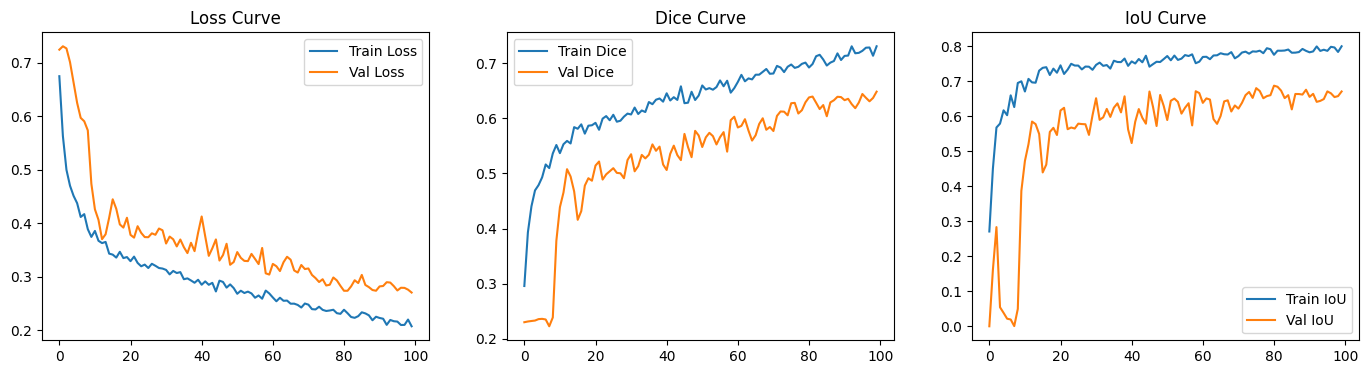

In [7]:
# =============================================================
# LOSS + METRICS
# =============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import copy
import matplotlib.pyplot as plt


# BCE + Dice Loss
class BCEDiceLoss(nn.Module):
    def __init__(self, smooth=1e-5):
        super().__init__()
        self.smooth = smooth
        self.bce = nn.BCELoss()

    def forward(self, preds, targets):
        bce_loss = self.bce(preds, targets)

        preds_f = preds.view(-1)
        targets_f = targets.view(-1)
        inter = (preds_f * targets_f).sum()
        dice_loss = 1 - (2 * inter + self.smooth) / \
                        (preds_f.sum() + targets_f.sum() + self.smooth)

        return 0.5 * bce_loss + 0.5 * dice_loss


# Dice Metric
def dice_coef(y_true, y_pred, smooth=1e-5):
    y_true_f = y_true.view(-1)
    y_pred_f = y_pred.view(-1)
    inter = (y_true_f * y_pred_f).sum()
    return (2. * inter + smooth) / (y_true_f.sum() + y_pred_f.sum() + smooth)


# IoU Metric
def iou_score(preds, masks, threshold=0.5, eps=1e-6):
    preds_bin = (preds > threshold).float()
    masks_bin = (masks > threshold).float()

    inter = (preds_bin * masks_bin).sum().item()
    union = preds_bin.sum().item() + masks_bin.sum().item() - inter

    return inter / (union + eps)


# =============================================================
# TRAINING LOOP
# =============================================================
def train_model(model, train_loader, val_loader, epochs=50):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)

    criterion = BCEDiceLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    # Tracking curves
    train_losses, val_losses = [], []
    train_dice_scores, val_dice_scores = [], []
    train_iou_scores, val_iou_scores = [], []

    best_val_loss = float("inf")
    best_epoch = 0
    best_model_weights = None

    for epoch in range(epochs):

        # ------------------ TRAIN ------------------
        model.train()
        train_loss = train_dice = train_iou = 0

        for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            images, masks = images.to(device), masks.to(device)

            preds = model(images)
            loss = criterion(preds, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Accumulate
            train_loss += loss.item()
            train_dice += dice_coef(masks, preds).item()
            train_iou += iou_score(preds, masks)

        # ------------------ VALIDATION ------------------
        model.eval()
        val_loss = val_dice = val_iou = 0

        with torch.no_grad():
            for images, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                images, masks = images.to(device), masks.to(device)

                preds = model(images)
                val_loss += criterion(preds, masks).item()
                val_dice += dice_coef(masks, preds).item()
                val_iou += iou_score(preds, masks)

        # ------------------ AVERAGES ------------------
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss   = val_loss / len(val_loader)
        avg_train_dice = train_dice / len(train_loader)
        avg_val_dice   = val_dice / len(val_loader)
        avg_train_iou  = train_iou / len(train_loader)
        avg_val_iou    = val_iou / len(val_loader)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_dice_scores.append(avg_train_dice)
        val_dice_scores.append(avg_val_dice)
        train_iou_scores.append(avg_train_iou)
        val_iou_scores.append(avg_val_iou)

        # ------------------ PRINT ------------------
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        print(f"Train Dice: {avg_train_dice:.4f} | Val Dice: {avg_val_dice:.4f}")
        print(f"Train IoU : {avg_train_iou:.4f} | Val IoU : {avg_val_iou:.4f}")

        # ------------------ SAVE BEST ------------------
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_epoch = epoch + 1
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), "best_unet_monu.pth")
            print(f"✅ Best model saved (Epoch {epoch+1}, Val Loss {best_val_loss:.4f})")

    # ------------------ LOAD BEST MODEL ------------------
    model.load_state_dict(best_model_weights)

    print("\n🎉 Training Completed!")
    print(f"🏆 Best Epoch: {best_epoch}")
    print(f"✔ Best Val Loss: {best_val_loss:.4f}")

    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_dice": train_dice_scores,
        "val_dice": val_dice_scores,
        "train_iou": train_iou_scores,
        "val_iou": val_iou_scores,
    }


# =============================================================
# PLOTTING FUNCTION
# =============================================================
def plot_training(history):
    plt.figure(figsize=(17, 4))

    # Loss
    plt.subplot(1, 3, 1)
    plt.plot(history["train_losses"], label="Train Loss")
    plt.plot(history["val_losses"], label="Val Loss")
    plt.title("Loss Curve")
    plt.legend()

    # Dice
    plt.subplot(1, 3, 2)
    plt.plot(history["train_dice"], label="Train Dice")
    plt.plot(history["val_dice"], label="Val Dice")
    plt.title("Dice Curve")
    plt.legend()

    # IoU
    plt.subplot(1, 3, 3)
    plt.plot(history["train_iou"], label="Train IoU")
    plt.plot(history["val_iou"], label="Val IoU")
    plt.title("IoU Curve")
    plt.legend()

    plt.show()

model = unet_CBAM().to(device)
history = train_model(model, train_loader, val_loader, epochs=100)
plot_training(history)

In [8]:
# =============================================================
# Simplified Test Evaluation (Only Dice and IoU)
# =============================================================

import numpy as np

def iou_coef(y_true, y_pred, smooth=1e-5):
    """
    Intersection over Union (IoU) metric for binary masks.
    """
    y_true_f = y_true.view(-1)
    y_pred_f = y_pred.view(-1)
    intersection = (y_true_f * y_pred_f).sum()
    union = y_true_f.sum() + y_pred_f.sum() - intersection
    return (intersection + smooth) / (union + smooth)

# Load the best model
print("📥 Loading best model...")
model.load_state_dict(torch.load("best_unet_monu.pth", map_location=device))
model.eval()

# Initialize accumulators for metrics
test_dice, test_iou = 0, 0

print("🧪 Evaluating on test set...")

# Loop through test data
with torch.no_grad():
    for images, masks in tqdm(test_loader, desc="Evaluating Test Set"):
        images, masks = images.to(device), masks.to(device)
        preds = model(images)
        preds_bin = (preds > 0.5).float()   # threshold at 0.5

        # Accumulate metrics
        test_dice += dice_coef(masks, preds_bin).item()
        test_iou += iou_coef(masks, preds_bin).item()

# Average metrics
num_batches = len(test_loader)
avg_test_dice = test_dice / num_batches
avg_test_iou = test_iou / num_batches

# Print simplified results
print("\n" + "="*40)
print("🎯 TEST SET EVALUATION")
print("="*40)
print(f"✅ Dice Coefficient: {avg_test_dice:.4f}")
print(f"✅ IoU (Jaccard):    {avg_test_iou:.4f}")
print("="*40)

# =============================================================
# Simplified Visualization (Only Dice and IoU)
# =============================================================

def dice_coef_single(y_true, y_pred, smooth=1e-5):
    """Compute Dice coefficient for one pair of masks"""
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()
    intersection = np.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (np.sum(y_true_f) + np.sum(y_pred_f) + smooth)

def iou_coef_single(y_true, y_pred, smooth=1e-5):
    """Compute IoU for one pair of masks"""
    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - intersection
    return intersection / (union + smooth)

def visualize_predictions_simple(model, dataset, num_samples=5, threshold=0.5):
    """
    Simplified visualization with dice, iou and error analysis
    """
    indices = random.sample(range(len(dataset)), num_samples)
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, num_samples * 4))
    
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i, idx in enumerate(indices):
        image, mask = dataset[idx]

        with torch.no_grad():
            pred_prob = model(image.unsqueeze(0).to(device)).cpu().squeeze().numpy()

        pred_mask = (pred_prob > threshold).astype(np.uint8)
        true_mask = mask.squeeze().numpy().astype(np.uint8)
        
        # Compute metrics
        dice_score = dice_coef_single(true_mask, pred_mask) * 100
        iou_score = iou_coef_single(true_mask, pred_mask) * 100
        
        # Create error map (FP: red, FN: blue, TP: white, TN: black)
        error_map = np.zeros((*true_mask.shape, 3), dtype=np.uint8)
        true_positive = (true_mask == 1) & (pred_mask == 1)
        false_positive = (true_mask == 0) & (pred_mask == 1)
        false_negative = (true_mask == 1) & (pred_mask == 0)
        
        error_map[true_positive] = [255, 255, 255]  # White for TP
        error_map[false_positive] = [255, 0, 0]     # Red for FP
        error_map[false_negative] = [0, 0, 255]     # Blue for FN

        # Plot 1: Original Image
        axes[i, 0].imshow(image.permute(1, 2, 0) if image.shape[0] == 3 else image.squeeze(), cmap='gray')
        axes[i, 0].set_title(f"Input Image {idx}")
        axes[i, 0].axis("off")
        
        # Plot 2: Ground Truth
        axes[i, 1].imshow(true_mask, cmap="gray")
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")
        
        # Plot 3: Predicted Mask
        axes[i, 2].imshow(pred_mask, cmap="gray")
        axes[i, 2].set_title(f"Prediction\nDice: {dice_score:.1f}% | IoU: {iou_score:.1f}%")
        axes[i, 2].axis("off")
        
        # Plot 4: Error Analysis
        axes[i, 3].imshow(error_map)
        axes[i, 3].set_title("Error Analysis\n(Red: FP, Blue: FN)")
        axes[i, 3].axis("off")
        
        # Add legend for error map (only for first row)
        if i == 0:
            from matplotlib.patches import Patch
            legend_elements = [
                Patch(facecolor='white', label='True Positive'),
                Patch(facecolor='red', label='False Positive'),
                Patch(facecolor='blue', label='False Negative')
            ]
            axes[i, 3].legend(handles=legend_elements, loc='upper right', fontsize=8)

    plt.tight_layout()
    plt.show()
    
    return indices

# Run simplified visualization
print("\n📊 Generating visualizations...")
sampled_indices = visualize_predictions_simple(model, test_dataset, num_samples=5)

print("\n🎉 Evaluation completed successfully!")

📥 Loading best model...
🧪 Evaluating on test set...


Evaluating Test Set: 100%|██████████| 2/2 [00:00<00:00,  7.21it/s]


🎯 TEST SET EVALUATION
✅ Dice Coefficient: 0.7160
✅ IoU (Jaccard):    0.5643

📊 Generating visualizations...


ValueError: Sample larger than population or is negative